# импорт нужных библиотек


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# загрузка фото
разбиение на тензоры RGB
проверка размера

In [4]:
img = mpimg.imread('minion.jpg')
R = img[:, :, 0].astype(float)
G = img[:, :, 1].astype(float)
B = img[:, :, 2].astype(float)

print(f'size of img: {img.shape}\n')
print(R, G, B)


size of img: (1024, 1024, 3)

[[43. 46. 51. ... 69. 68. 68.]
 [44. 46. 49. ... 69. 68. 68.]
 [46. 46. 46. ... 68. 67. 67.]
 ...
 [15. 15. 15. ... 22. 22. 21.]
 [16. 16. 16. ... 22. 22. 22.]
 [16. 16. 16. ... 23. 22. 22.]] [[33. 36. 41. ... 32. 31. 31.]
 [34. 36. 39. ... 32. 31. 31.]
 [36. 36. 36. ... 31. 30. 30.]
 ...
 [22. 22. 22. ... 22. 22. 21.]
 [23. 23. 23. ... 22. 22. 22.]
 [23. 23. 23. ... 23. 22. 22.]] [[34. 37. 42. ... 16. 15. 15.]
 [35. 37. 38. ... 16. 15. 15.]
 [37. 35. 35. ... 15. 14. 14.]
 ...
 [40. 40. 40. ... 34. 34. 33.]
 [41. 41. 41. ... 34. 34. 34.]
 [41. 41. 41. ... 35. 34. 34.]]


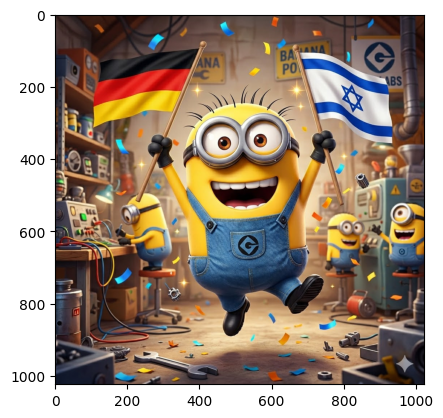

In [5]:
plt.imshow(img)

# степенной метод (пунтк №2)
формула сингулярного разложения: $A=UΣV^T$

In [6]:
def svd(A, singular_values, iter):
  U_cols, sigmas, V_cols = [], [], []
  A_curr = A.copy()

  for _ in range(singular_values):
    # random start vector
    v = np.random.randn(A_curr.shape[1])
    v = v / np.linalg.norm(v)

    # iterations
    for _ in range(iter):
      u = A_curr @ v
      sigma = np.linalg.norm(u)
      u = u / sigma
      v = A_curr.T @ u
      v = v / np.linalg.norm(v)

    U_cols.append(u)
    sigmas.append(sigma)
    V_cols.append(v)
    # вычитаем найденный вклад
    A_curr = A_curr - sigma * np.outer(u, v)

  return np.array(U_cols).T, np.array(sigmas), np.array(V_cols).T

# запуск сингулярного разложения степенным методом

In [7]:
k = 200  # сколько сингулярных чисел берём

for iter in [10, 50, 100]:
    U, S, V = svd(R, k, iter)
    R_restored = U @ np.diag(S) @ V.T
    error = np.linalg.norm(R - R_restored)
    print(f'iter={iter}, ошибка={error:.4f}')

iter=10, ошибка=5728.3830
iter=50, ошибка=5716.9867
iter=100, ошибка=5716.9540


ошибка ||A - U∑$V^T$|| показывает насколько воссстановленная матрица отличается от оригинала

результаты при k = 50:
  - iter=10, ошибка=9650.0330
  - iter=50, ошибка=9633.8963
  - iter=100, ошибка=9633.7525

результаты при k = 200:
  - iter=10, ошибка=2562.8590
  - iter=50, ошибка=2556.9908
  - iter=100, ошибка=2556.7037

  ### вывод по пункту 2:
  ошибка падает в зависимости от кол-ва сингулярных чисел и кол-ва итераций (но эт не сильно влияет) ⇒ улучшается точность
  
  !!! после 50 итераций ошибка почти сходится ⇒ увеличивать кол-во итераций (>100) не имеет смысла

# анализ сингулярных чисел и усеченное SVD (пунткт №3)

связь ошибки усеченного SVD со следующим сингулярным числом: $∥A−A_k​∥=σ_{k+1}​$

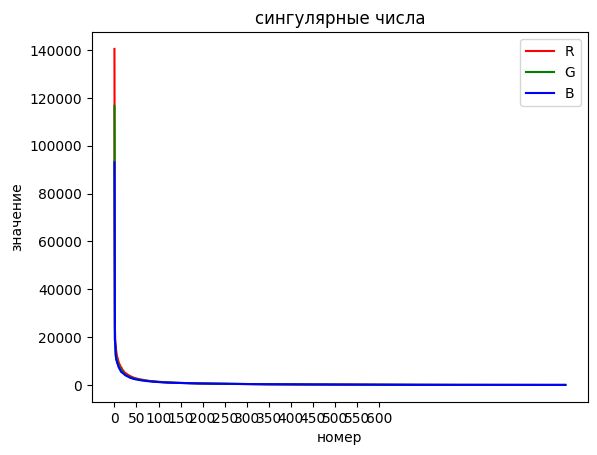

In [8]:
# get singular values
U_r, S_r, V_r = np.linalg.svd(R, full_matrices=False)
U_g, S_g, V_g = np.linalg.svd(G, full_matrices=False)
U_b, S_b, V_b = np.linalg.svd(B, full_matrices=False)

plt.plot(range(len(S_r)), S_r, color='red',label='R')
plt.plot(range(len(S_g)), S_g, color='green',label='G')
plt.plot(range(len(S_b)), S_b, color='blue',label='B')
plt.xticks(range(0, 640, 50))
plt.xlabel('номер')
plt.ylabel('значение')
plt.title('сингулярные числа')
plt.legend()
plt.show()

### а) анализ графика
1) резкое падение в начале первые синг числа (<50) огромные (>80000), потом кривая обваливается ⇒ большая часть информации хранится в в первых нескольких компонентах

2) начиная с 50 номера кривая почти плоска, значения не меняются, т.е. их в клад в фотокарточку не значителен

3) все три канала ведут себя схоже, но R > G > B (в начале)

### б) предположить сколько нужно k
кривая резко убывает до 50, после практически не меняется. предположим, что k=range(0, 50) должно быть достаточно для приемлимого качества

### с) реализация усеченного разложения
$A_k =U_kΣ_kV^T_k , k ≪ min(n,m)$

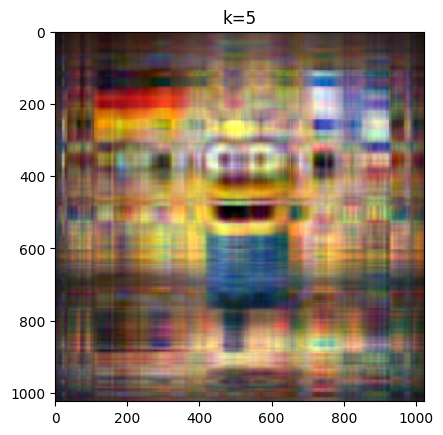

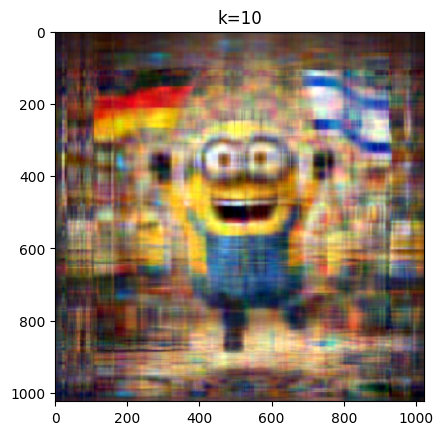

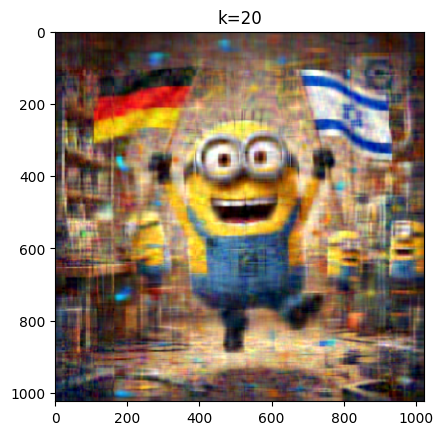

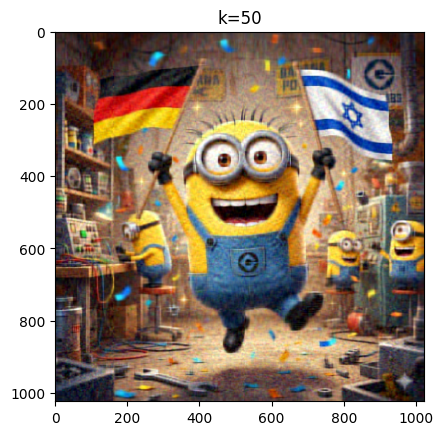

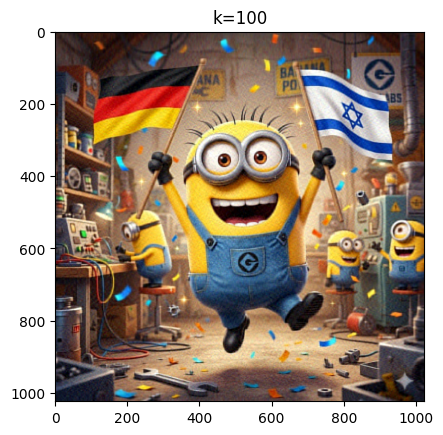

In [9]:
for k in [5, 10, 20, 50, 100]:
  R_k = U_r[:, :k]  @  np.diag(S_r[:k])  @  V_r[:k, :]
  G_k = U_g[:, :k]  @  np.diag(S_g[:k])  @  V_g[:k, :]
  B_k = U_b[:, :k]  @  np.diag(S_b[:k])  @  V_b[:k, :]

  img_restored = np.clip(np.stack([R_k, G_k, B_k], axis=2), 0, 255).astype(np.uint8)

  plt.figure()
  plt.title(f'k={k}')
  plt.imshow(img_restored)
  plt.show() # хуй

### d) вывод про картинку
картинка после восстановления стало визуально приемлимой на k=50
тк начиная с этого значения картинка визуально не отличается от оригинала, при этом объем данных значительно меньше